# Hotel Booking Cancellation Prediction
## Sprint 3: Optimization & Final Model
**Goal: Improve model performance and reliability**

In [92]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [94]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report,
ConfusionMatrixDisplay, roc_auc_score, roc_curve)

In [95]:
from sklearn.ensemble import StackingClassifier

In [96]:
pd.set_option("display.max_columns",None)

# Load the data

In [97]:
df_pp = pd.read_csv(r'C:\Users\laksh\ML\ML Project\preprocessed_df')
df_pp.drop('sc__days_in_waiting_list.1',axis=1,inplace=True)
print('Shape:',df_pp.shape)

X = df_pp.drop(['remainder__is_canceled',],axis=1)
y = df_pp['remainder__is_canceled']

X.drop(y[y.isna()].index,inplace=True)
y.drop(y[y.isna()].index,inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Shape: (86940, 233)
Train: (69552, 232), Test: (17388, 232)


---
# Step 1: Feature Engineering
Creating new useful features from the exitsing data

In [98]:
# Work on a copy
X_fe = X.copy()

### 1. Total stay nights

In [99]:
X_fe['fe__total_nights'] = X_fe['sc__stays_in_week_nights'] + X_fe['sc__stays_in_weekend_nights']

### 2. Cancellation history ratio  (previous cancellations / total previous bookings)

In [100]:
total_prev = X_fe['sc__previous_cancellations'] + X_fe['sc__previous_bookings_not_canceled']
X_fe['fe__cancel_ratio'] = X_fe['sc__previous_cancellations'] / (total_prev + 1)

### 3. Interaction: lead_time × cancel_ratio (high lead time + history of cancellation)

In [101]:
X_fe['fe__lead_x_cancel'] = X_fe['sc__lead_time_log'] * X_fe['fe__cancel_ratio']

### 4. Waiting days flag (was the customer on a waitlist?)

In [102]:
X_fe['fe__was_waitlisted'] = (X_fe['sc__days_in_waiting_list'] > 0).astype(int)

In [103]:
print('New features added:', ['fe__total_nights', 'fe__cancel_ratio', 'fe__lead_x_cancel', 'fe__was_waitlisted'])
print('New shape:', X_fe.shape)

New features added: ['fe__total_nights', 'fe__cancel_ratio', 'fe__lead_x_cancel', 'fe__was_waitlisted']
New shape: (86940, 236)


### Check correlation of new features with target


In [104]:
fe_corr = pd.DataFrame({
    'Feature': ['fe__total_nights', 'fe__cancel_ratio', 'fe__lead_x_cancel', 'fe__was_waitlisted'],
    'Correlation with Target': [
        X_fe['fe__total_nights'].corr(y),
        X_fe['fe__cancel_ratio'].corr(y),
        X_fe['fe__lead_x_cancel'].corr(y),
        X_fe['fe__was_waitlisted'].corr(y)
    ]
}).sort_values('Correlation with Target', key=abs, ascending=False)

print(fe_corr.to_string(index=False))

           Feature  Correlation with Target
  fe__cancel_ratio                 0.139246
 fe__lead_x_cancel                -0.088985
  fe__total_nights                 0.080858
fe__was_waitlisted                 0.014750


In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

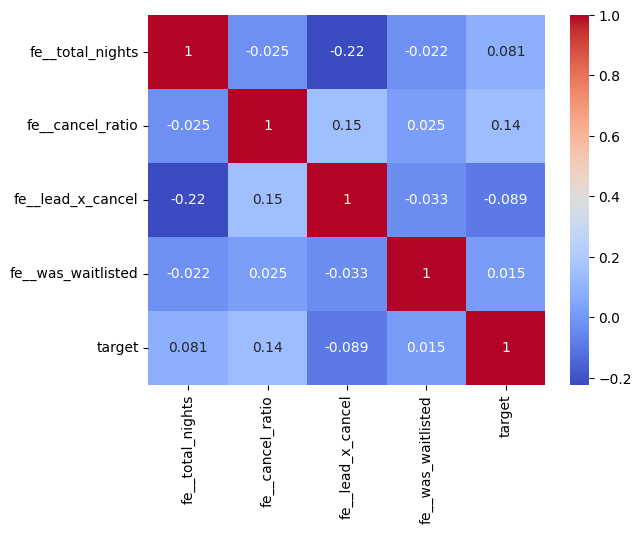

In [106]:
corr_df = X_fe[['fe__total_nights',
                'fe__cancel_ratio',
                'fe__lead_x_cancel',
                'fe__was_waitlisted']].copy()

corr_df['target'] = y

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

---
### Save Feature Engineering Logic (for Sprint 4 Pipeline)

The 4 engineered features above were created with inline pandas code. So that Sprint 4 can **replay the exact same transformations** inside an end-to-end `Pipeline`, we save this logic as a reusable scikit-learn transformer class (`FeatureEngineer`) in `src/feature_engineering.py`. We also define a `FeatureSelector` transformer here, which we'll use after Step 2 (Feature Selection) to keep only the top-N columns.

In [107]:
import os

os.makedirs('src', exist_ok=True)

feature_engineering_code = '''
from sklearn.base import BaseEstimator, TransformerMixin


class FeatureEngineer(BaseEstimator, TransformerMixin):
    \"\"\"
    Adds the Sprint 3 engineered features on top of the Sprint 1
    preprocessed columns:
      - fe__total_nights
      - fe__cancel_ratio
      - fe__lead_x_cancel
      - fe__was_waitlisted

    Designed to be used as a step inside an sklearn Pipeline, placed
    AFTER the preprocessor (ColumnTransformer) and BEFORE the model.
    \"\"\"

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X['fe__total_nights'] = X['sc__stays_in_week_nights'] + X['sc__stays_in_weekend_nights']

        total_prev = X['sc__previous_cancellations'] + X['sc__previous_bookings_not_canceled']
        X['fe__cancel_ratio'] = X['sc__previous_cancellations'] / (total_prev + 1)

        X['fe__lead_x_cancel'] = X['sc__lead_time_log'] * X['fe__cancel_ratio']

        X['fe__was_waitlisted'] = (X['sc__days_in_waiting_list'] > 0).astype(int)

        return X


class FeatureSelector(BaseEstimator, TransformerMixin):
    \"\"\"
    Selects a fixed list of columns (the top-N features chosen in
    Sprint 3 via feature importance). Used as the final preprocessing
    step before the model in the Sprint 4 pipeline.
    \"\"\"

    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.columns]
'''

with open('src/feature_engineering.py', 'w') as f:
    f.write(feature_engineering_code)

print('src/feature_engineering.py written')

src/feature_engineering.py written


In [108]:
# Quick sanity check: verify the saved class reproduces the same features
import sys
sys.path.append('src')
from feature_engineering import FeatureEngineer

fe_check = FeatureEngineer().fit_transform(X.copy())
print('Columns match manual FE:', 
      set(['fe__total_nights','fe__cancel_ratio','fe__lead_x_cancel','fe__was_waitlisted'])
      .issubset(set(fe_check.columns)))
print(fe_check[['fe__total_nights','fe__cancel_ratio','fe__lead_x_cancel','fe__was_waitlisted']].head(3))

Columns match manual FE: True
   fe__total_nights  fe__cancel_ratio  fe__lead_x_cancel  fe__was_waitlisted
0         -2.265476         -0.100315          -0.141983                   0
1         -2.265476         -0.100315          -0.189297                   0
2         -1.776178         -0.100315           0.090097                   0


  # Step 2: Feature Selection

In [109]:
# Train-test split on engineered features
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y, test_size=0.2, random_state=42, stratify=y
)

**Feature Importance via Random Forest**

In [110]:
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_fe, y_train_fe)

feat_imp = pd.Series(rf_selector.feature_importances_, index=X_fe.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=False)

In [111]:
print("Top 20 features by importance:")
print(feat_imp_sorted.head(20))

Top 20 features by importance:
fe__lead_x_cancel                     0.138906
sc__lead_time_log                     0.138774
sc__adr_capped                        0.132854
fe__total_nights                      0.059548
sc__stays_in_week_nights              0.045054
ohe__country_PRT                      0.038763
ohe__market_segment_Online TA         0.028468
sc__stays_in_weekend_nights           0.027432
sc__adults                            0.020945
fe__cancel_ratio                      0.014578
ohe__customer_type_Transient          0.014500
ohe__deposit_type_Non Refund          0.014059
ohe__hotel_Resort Hotel               0.013510
ohe__assigned_room_type_D             0.013495
ohe__market_segment_Offline TA/TO     0.012136
ohe__reserved_room_type_D             0.011064
ohe__arrival_date_month_August        0.010421
ohe__arrival_date_month_July          0.009854
ohe__customer_type_Transient-Party    0.009742
ohe__arrival_date_month_May           0.009586
dtype: float64


In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
feat_imp_sorted.head(20).plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('Top 20 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.

<Figure size 1200x600 with 0 Axes>

In [ ]:
len(

**Use top-N features based on importance**

In [115]:
top_n = 30

feat_imp_sorted = feat_imp.sort_values(ascending=False)

top_features = feat_imp_sorted.index

X_train_sel = X_train_fe[top_features]
X_test_sel  = X_test_fe[top_features]

In [83]:
X_train_sel.drop('sc__days_in_waiting_list.1',axis=1,inplace=True)
X_test_sel.drop('sc__days_in_waiting_list.1',axis=1,inplace=True)

In [90]:
top_features.drop('sc__days_in_waiting_list.1')

Index(['sc__lead_time_log', 'fe__lead_x_cancel', 'sc__adr_capped',
       'fe__total_nights', 'sc__stays_in_week_nights', 'ohe__country_PRT',
       'ohe__market_segment_Online TA', 'sc__stays_in_weekend_nights',
       'sc__adults', 'fe__cancel_ratio',
       ...
       'ohe__country_SDN', 'ohe__country_NPL', 'ohe__country_MDG',
       'ohe__country_LAO', 'ohe__country_BWA', 'ohe__country_GUY',
       'ohe__country_PLW', 'ohe__country_PYF', 'ohe__country_NAM',
       'ohe__assigned_room_type_L'],
      dtype='str', length=236)

# Step 3: Hyperparameter Tuning

In [118]:
!pip install optuna

In [119]:
import pandas as pd
import optuna

In [120]:
from sklearn.model_selection import cross_val_score

### 1. Create Objective Function

In [121]:
def objective(trial):

    n_estimators = trial.suggest_int(
        'n_estimators',
        50,
        300
    )

    max_depth = trial.suggest_int(
        'max_depth',
        2,
        30
    )

    min_samples_split = trial.suggest_int(
        'min_samples_split',
        2,
        10
    )
    min_samples_leaf = trial.suggest_int(
        'min_samples_leaf',
        1,
        5
    )

    model = RandomForestClassifier(

        n_estimators=n_estimators,

        max_depth=max_depth,

        min_samples_split=min_samples_split,

        random_state=42
    )

    score = cross_val_score(

        model,

        X_train_sel,

        y_train_fe,

        cv=5,

        scoring='accuracy'
    ).mean()

    return score

### 2. Create Study

In [ ]:
study = optuna.create_study(

    direction='maximize'
)

[I 2026-06-12 04:04:12,063] A new study created in memory with name: no-name-02c20a42-f31a-4d43-b627-969118f5787e


### 5. Start Optimization

In [ ]:
study.optimize(

    objective,

    n_trials=30
)

[I 2026-06-12 04:05:28,945] Trial 0 finished with value: 0.7659593003710917 and parameters: {'n_estimators': 115, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.7659593003710917.
[I 2026-06-12 04:06:05,539] Trial 1 finished with value: 0.7835288646355663 and parameters: {'n_estimators': 56, 'max_depth': 22, 'min_samples_split': 8, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.7835288646355663.
[I 2026-06-12 04:07:23,341] Trial 2 finished with value: 0.7848947636254527 and parameters: {'n_estimators': 114, 'max_depth': 23, 'min_samples_split': 8, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.7848947636254527.
[I 2026-06-12 04:09:09,373] Trial 3 finished with value: 0.7836870138971683 and parameters: {'n_estimators': 160, 'max_depth': 21, 'min_samples_split': 4, 'min_samples_leaf': 1}. Best is trial 2 with value: 0.7848947636254527.
[I 2026-06-12 04:10:24,499] Trial 4 finished with value: 0.765269155602053 and parameters: {'

In [ ]:
best_param=study.best_params
best_param

{'n_estimators': 234,
 'max_depth': 30,
 'min_samples_split': 4,
 'min_samples_leaf': 3}

In [ ]:
study.best_value


0.7947435109330387

# Ensemble Learning

In [122]:
stack = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators= 194,
                                      max_depth= 30,
                                      min_samples_split= 7,
                                      min_samples_leaf= 4)),
        ('dt', DecisionTreeClassifier()),
        ('nb', GaussianNB())
    ],
    final_estimator=LogisticRegression()
)

In [123]:
stack.fit(X_train_sel, y_train_fe)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('dt', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",194
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples re

In [124]:
y_pred = stack.predict(X_test_sel)

In [125]:
pred=stack.predict(X_train_sel)
accuracy_score(y_train_fe,pred)

0.8619306418219461

In [126]:
accuracy_score(y_test,y_pred)

0.7922705314009661

# Final Model

In [127]:
final_model = stack

In [128]:
pred=final_model.predict(X_train_sel)
accuracy_score(y_train_fe,pred)

0.8619306418219461

In [129]:
y_pred = final_model.predict(X_test_sel)

In [130]:
accuracy_score(y_test,y_pred)

0.7922705314009661

---
# Step 4: Model Serialization (for Sprint 4 Pipeline)

In [133]:
import joblib
import json
import os

os.makedirs('models', exist_ok=True)

# 1. Save the final trained model (Stacking Classifier)
joblib.dump(final_model, 'models/final_model.pkl')
print('Final model saved: models/final_model.pkl')

# 2. Save the list of selected top-N features (order matters!)
with open('models/selected_features.json', 'w') as f:
    json.dump(top_features.tolist(), f)
print('Selected features saved: models/selected_features.json')

print(f'\nFinal Test Accuracy: {accuracy_score(y_test_fe, y_pred):.4f}')

Final model saved: models/final_model.pkl
Selected features saved: models/selected_features.json

Final Test Accuracy: 0.7923


In [134]:
# Verify everything reloads correctly
import joblib

loaded_model = joblib.load('models/final_model.pkl')
with open('models/selected_features.json') as f:
    loaded_features = json.load(f)

check_pred = loaded_model.predict(X_test_sel[loaded_features][:5])
print('Reload check predictions:', check_pred)
print('Sprint 3 artifacts ready for Sprint 4:')
print('  - models/preprocessor.pkl       (from Sprint 1)')
print('  - src/feature_engineering.py    (FeatureEngineer, FeatureSelector)')
print('  - models/final_model.pkl        (Stacking Classifier)')
print('  - models/selected_features.json (top 30 feature names)')

Reload check predictions: [0. 0. 1. 0. 1.]
Sprint 3 artifacts ready for Sprint 4:
  - models/preprocessor.pkl       (from Sprint 1)
  - src/feature_engineering.py    (FeatureEngineer, FeatureSelector)
  - models/final_model.pkl        (Stacking Classifier)
  - models/selected_features.json (top 30 feature names)
